In [1]:
import pandas as pd
import numpy as np
import pickle
import networkx as nx
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import chain, product


## Load data

In [2]:
GRAPHS = {"invariant": "/homes/shahashka/lucid_cd/data/rpe1_experiment2/bootstrap_graphs3/dag_gnn_combined.gexf",
          "F":"/homes/shahashka/lucid_cd/data/rpe1_experiment2/bootstrap_graphs2/dag_gnn_full_doseF.gexf",
          "G":"/homes/shahashka/lucid_cd/data/rpe1_experiment2/bootstrap_graphs2/dag_gnn_full_doseG.gexf",
          "H":"/homes/shahashka/lucid_cd/data/rpe1_experiment2/bootstrap_graphs2/dag_gnn_full_doseH.gexf",
          "I":"/homes/shahashka/lucid_cd/data/rpe1_experiment2/bootstrap_graphs2/dag_gnn_full_doseI.gexf",
          "J":"/homes/shahashka/lucid_cd/data/rpe1_experiment2/bootstrap_graphs2/dag_gnn_full_doseJ.gexf" 
          }
with open("/homes/shahashka/lucid_cd/data/gene_groups.pkl", "rb") as f:
    CAUSAL_TFS, CAUSAL_NEIGHBORHOODS, KOSMOS, CHATGPT, BNL = pickle.load(f)
EXPERIMENT = "./data/rpe1_experiment2"
CONTEXT_SPECIFIC_GRAPHS = f"{EXPERIMENT}/bootstrap_graphs2"
INVARIANT_GRAPHS = f"{EXPERIMENT}/bootstrap_graphs3"
CAUSAL_DOSE_RATES = ["dF", "dG", "dH", "dI", "dJ"]
DOSE_RATES = ["F", "G", "H", "I", "J"]
DOSE_RATES_ACTUAL = {"F": 0.38, "G": 0.28, "H": 0.55, "I": 6.66, "J": 12.11}
WEEKS = np.arange(10)


In [3]:
log2fold_df = pd.read_csv(f"/homes/shahashka/lucid_cd/data/rpe1_experiment2/rpe1_9week_study_experiment2_diffexp_deseq_vs_control_all_dG_W2_adjust.txt", sep="\t")
print(len(set(log2fold_df["Gene"])))
log2fold_df = log2fold_df.loc[log2fold_df['padj'] < 0.05] # This is new, I think I should filter by p value. However this means there are no genes that DE across all dose rates
log2fold_df = log2fold_df.loc[abs(log2fold_df['log2FoldChange']) > 1]
print(len(set(log2fold_df["Gene"])))
log2fold_df['Week'] = [float(w[1]) for w in log2fold_df['Week']]
genes_by_week = {}
genes_by_dose = {} # TODO this is built incorrectly, there may be genes assigned to multiple weeks 
for i in WEEKS:
    week_i = log2fold_df.loc[log2fold_df["Week"] == i]
    genes_week_i = set(week_i["Gene"])
    for g in genes_week_i:
        if g in genes_by_week.keys():
            genes_by_week[g].add(i)
        else:
            genes_by_week[g] = set([i])
    print(i, len(genes_week_i))
for d in CAUSAL_DOSE_RATES:
    dose_i = log2fold_df.loc[log2fold_df["Dose"] == d]
    genes_dose_i = dose_i["Gene"]
    genes_by_dose[d[1]] = list(set(genes_dose_i))
    print(d, len(genes_by_dose[d[1]]))

50006
4223
0 0
1 498
2 2155
3 1693
4 943
5 369
6 1375
7 361
8 912
9 661
dF 2118
dG 2040
dH 671
dI 1551
dJ 3082


In [4]:
tpm_df_v1 = pd.read_csv(f"{EXPERIMENT}/cd_tpm_matrix_combined_dose_rate.csv", header=0)
print(tpm_df_v1.shape)
tpm_df_v2 = pd.read_csv(f"{EXPERIMENT}/rpe1_9week_study_experiment2_all_tpm.tsv", header=0, sep='\t')
print(len(set(tpm_df_v2["Gene"])))

(108, 11898)
48021


In [5]:
graphs = []
graphs_genes_by_dose = {}
for d,g in GRAPHS.items():
    G = nx.read_gexf(g)
    graphs.append(G)
    graphs_genes_by_dose[d] = list(G.nodes())

In [6]:
graphs_genes_by_dose.keys(), genes_by_dose.keys()

(dict_keys(['invariant', 'F', 'G', 'H', 'I', 'J']),
 dict_keys(['F', 'G', 'H', 'I', 'J']))

## Verify 1
- Q: Do log2fold differentially expressed genes (padj < 0.05, abs(log2fold) > 1) genes at each dose rate align with causal graph nodes?
- A: There are more differentially expressed genes than causal graph genes at each dose rate except dose rate H. The overlap is between 10-20%, relative to the smaller causal gene sets. So there is some overlap, but not as much as I would have thought

Text(0.5, 0, 'Dose Rate')

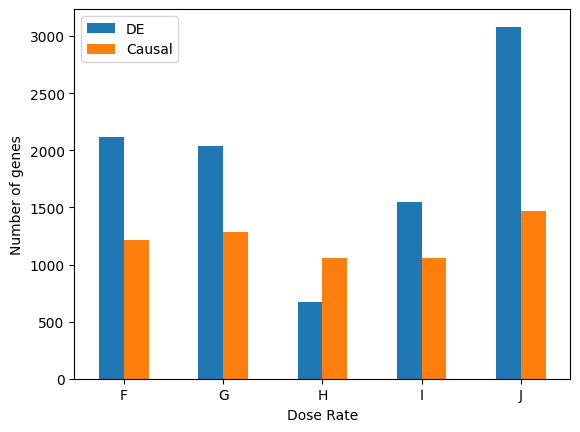

In [15]:
df_genes = pd.DataFrame({"DE": [len(gd) for gd in genes_by_dose.values()], "Causal": [len(gd) for i,gd in graphs_genes_by_dose.items() if i != "invariant"]}, index=DOSE_RATES)
ax = df_genes.plot.bar(rot=0)
ax.set_ylabel("Number of genes")
ax.set_xlabel("Dose Rate")

Text(0, 0.5, 'Dose Rate')

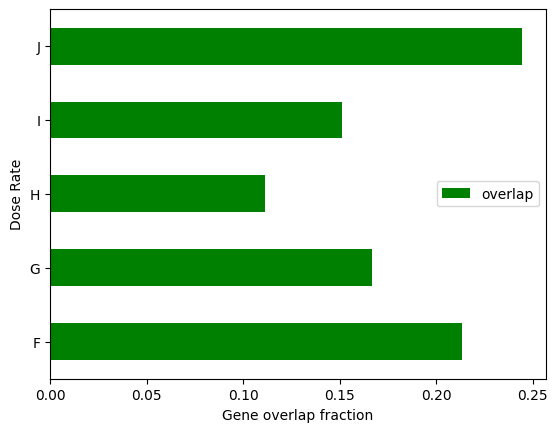

In [ ]:
df_genes['overlap'] = [len(set.intersection(set(genes_by_dose[i]), set(graphs_genes_by_dose[i])))/len(graphs_genes_by_dose[i]) for i in DOSE_RATES]
ax2 = df_genes.plot.barh(y='overlap', rot=0, color='green')
ax2.set_xlabel("Gene overlap fraction")
ax2.set_ylabel("Dose Rate")

## Verify 2
- Q: Does the topological order of DAGs (w.r.t 'radiation' source node) correlate to time. Are downstream nodes differentially expressed (padj <0.05, abs(log2fold) > 1) at later weeks?
- A: The distribution over weeks at each distance away from radiation is close to uniform. The median is almost equal across distance. This trend holds for the graph where all dose rates are considered, and we now look at the distance from the week node. 

The takeaway is that the causal graphs are not temporally aligned. Possibly because DAG-GNN was not tuned. Possibly because we included time as a random variable, this might break assumptions for causal discovery in this setting. Possibly temporal causal discovery methods are more appropriate. 

UPDATE after fix in genes_by_week to account for genes being assigned to multiple weeks. For a couple doses (F, G), further paths have a higher median. But not a consistent or compelling signal

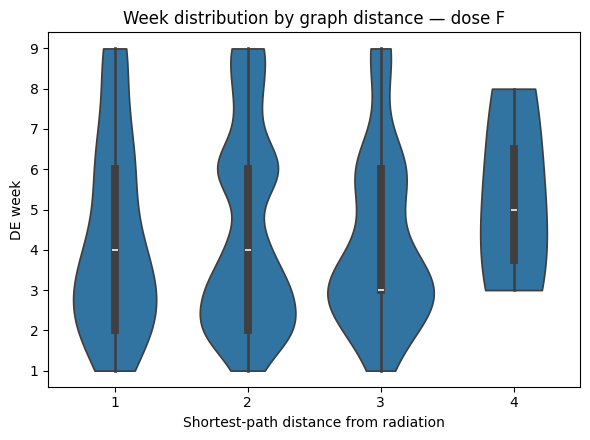

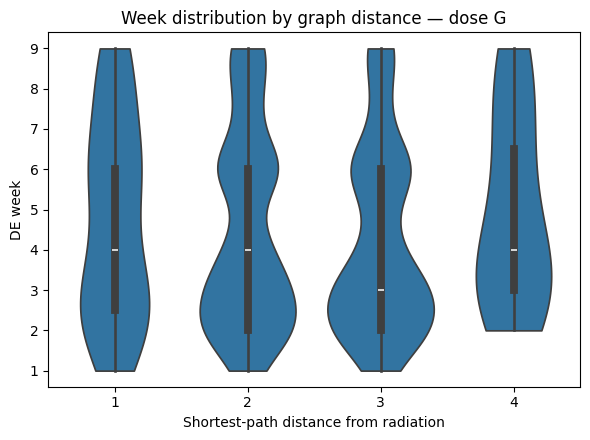

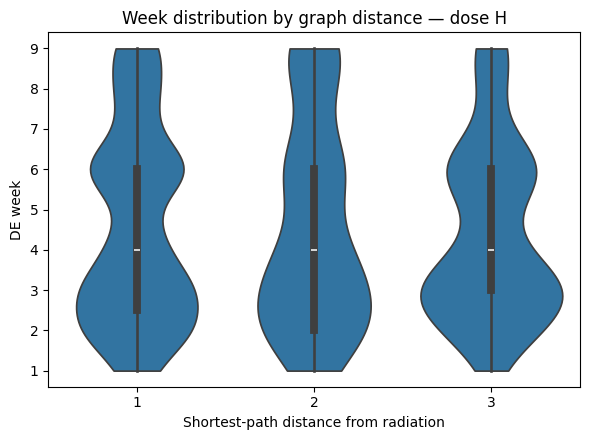

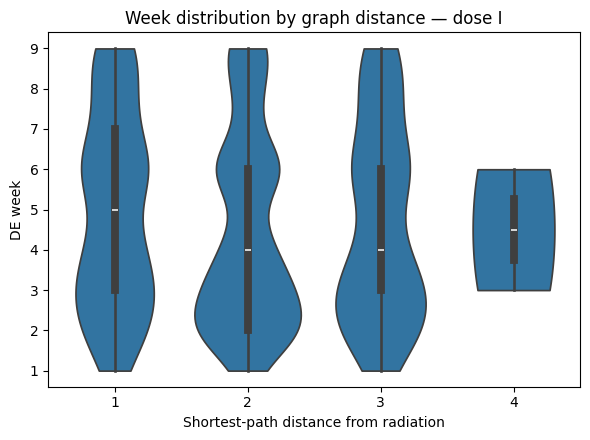

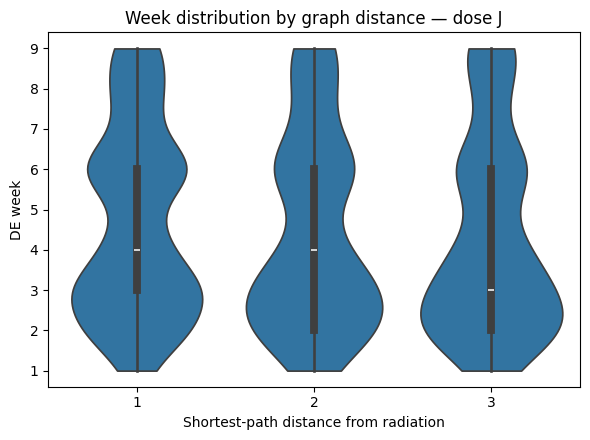

In [ ]:

for i, G in enumerate(graphs[1:]):
    source = "radiation"
    G = G.to_undirected()
    rows = []
    for g in G.nodes():
        if g in genes_by_week.keys() and nx.has_path(G, source=source, target=g):
            d = nx.shortest_path_length(G, source=source, target=g)
            weeks = genes_by_week[g] 
            for w in weeks:   # A gene can be differentially expressed in multiple weeks
                rows.append({"distance": d, "week": w})
    plot_df = pd.DataFrame(rows)
    if plot_df.empty:
        print(f"{DOSE_RATES[i]}: no genes with DE week + path from {source}")
        continue
    n_dist = plot_df["distance"].nunique()
    fig, ax = plt.subplots(figsize=(max(6.0, n_dist * 0.75), 4.5))
    sns.violinplot(
        data=plot_df,
        x="distance",
        y="week",
        inner="box",
        cut=0,
        ax=ax,
    )
    ax.set_xlabel("Shortest-path distance from radiation")
    ax.set_ylabel("DE week")
    ax.set_title(f"Week distribution by graph distance — dose {DOSE_RATES[i]}")
    plt.tight_layout()
    plt.show()

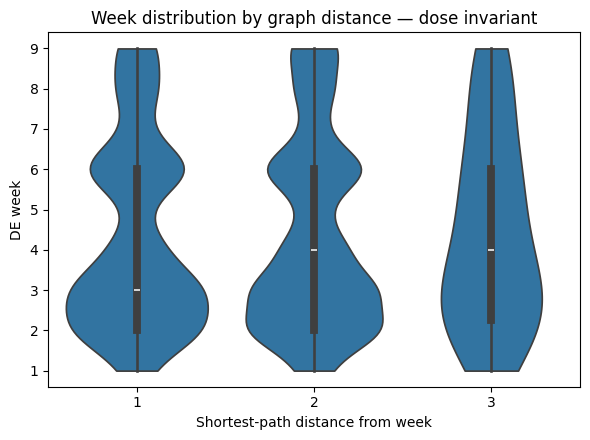

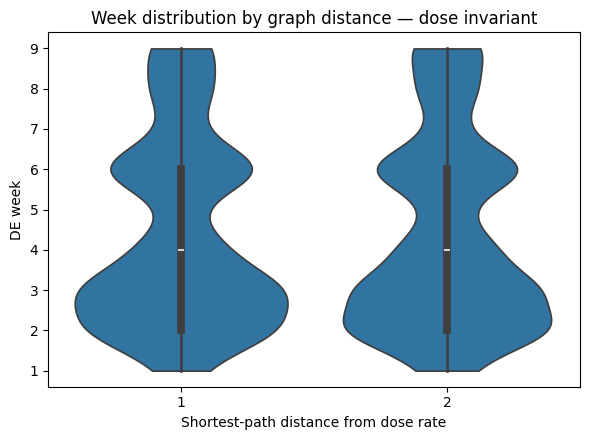

In [ ]:
source = "week"
G = graphs[0]
G = G.to_undirected()
rows = []
for g in G.nodes():
    if g in genes_by_week.keys() and nx.has_path(G, source=source, target=g):
        d = nx.shortest_path_length(G, source=source, target=g)
        weeks = genes_by_week[g] 
        for w in weeks:   # A gene can be differentially expressed in multiple weeks
            rows.append({"distance": d, "week": w})
plot_df = pd.DataFrame(rows)
if not plot_df.empty:
    n_dist = plot_df["distance"].nunique()
    fig, ax = plt.subplots(figsize=(max(6.0, n_dist * 0.75), 4.5))
    sns.violinplot(
        data=plot_df,
        x="distance",
        y="week",
        inner="box",
        cut=0,
        ax=ax,
    )
    ax.set_xlabel("Shortest-path distance from week")
    ax.set_ylabel("DE week")
    ax.set_title(f"Week distribution by graph distance — dose invariant")
    plt.tight_layout()
    plt.show()
    
    
source = "dose_rate"
rows = []
for g in G.nodes():
    if g in genes_by_week.keys() and nx.has_path(G, source=source, target=g):
        d = nx.shortest_path_length(G, source=source, target=g)
        weeks = genes_by_week[g] 
        for w in weeks:   # A gene can be differentially expressed in multiple weeks
            rows.append({"distance": d, "week": w})
plot_df = pd.DataFrame(rows)
if not plot_df.empty:
    n_dist = plot_df["distance"].nunique()
    fig, ax = plt.subplots(figsize=(max(6.0, n_dist * 0.75), 4.5))
    sns.violinplot(
        data=plot_df,
        x="distance",
        y="week",
        inner="box",
        cut=0,
        ax=ax,
    )
    ax.set_xlabel("Shortest-path distance from dose rate")
    ax.set_ylabel("DE week")
    ax.set_title(f"Week distribution by graph distance — dose invariant")
    plt.tight_layout()
    plt.show()

In [ ]:

all_edge_attr_names = set(chain.from_iterable(d.keys() for *_, d in G.edges(data=True)))

print(f"All unique edge attribute names: {all_edge_attr_names}")

All unique edge attribute names: {'count', 'weight', 'id'}


## Verify 3

- Q: Are pathways enriched across dose rate in a meaningful way for log2fold differentially expressed genes compared to causal genes? Compare to this paper: https://www.sciencedirect.com/science/article/pii/S2666555725000498
- A: Causal genes sets enrich more pathways and are much more statistically significant (relative to the full gene sets). I tried multiple databases and pathways taht overlap with those mentioned in the review paper. The trend is consistently in favor of causal gene sets, even though there are fewer dose rate causal gene sets that differentially expressed gene sets (F->J). This is a pretty strong result

In terms of dose dependent signal, we don't see stronger signals at higher or lower dose rates. Its mostly all over the place.

It is possible we would see temporal dependent signals, which we can do in another verification step.


In [30]:
from Bio import Entrez
from gprofiler import GProfiler
def bootstrap_enrichment_CI(genes, background_genes, n_boot, pathways) ->  pd.DataFrame:
    stats = {}
    for p in pathways:
        stats[p] = []
    
    for _ in range(n_boot):
        boot_genes = np.random.choice(genes, size=len(genes), replace=True)
        df = pathway_enrichment(boot_genes, background_genes, pathways)
        for _, row in df.iterrows():
                stats[row["native"]].append(-np.log10(row["p_value"]))

    ci = {}
    for pathway, values in stats.items():
        if len(values) > 10:
            ci[pathway] = {
                "mean": np.mean(values),
                "ci_low": np.percentile(values, 2.5),
                "ci_high": np.percentile(values, 97.5)
            }
        

    return ci

def pathway_enrichment(genes,background_genes, pathways) -> pd.DataFrame:
    """Given a list of genes, perform pathway enrichment using knowledge databases

    Args:
        genes (set(str)): Set of genes with string identifiers
        
    Returns:
        (List[Any]): Return a list of named pathways and scores for each 
    """
    gp = GProfiler(return_dataframe=True)

    results = gp.profile(
        organism="hsapiens",
        query=list(set(genes)),
        sources=["GO:BP","GO:MF", "GO:CC", "KEGG", "REAC", "WP"],
        user_threshold=0.05,
        background=background_genes, 
        significance_threshold_method="fdr",
    )

    # Sort by adjusted p-value
    results = results.sort_values("p_value")
    if pathways:
        return results.query("native in @pathways")
    else:
        return results

In [8]:
genes_100_tfs = {}
genes_neighborhoods = {}
for d in DOSE_RATES:
    genes_100_tfs[d] = pd.read_csv(f"{CONTEXT_SPECIFIC_GRAPHS}/top_100_dag_gnn_{d}.csv", header=None).iloc[:,0].to_list()
    genes_neighborhoods[d] = pd.read_csv(f"{CONTEXT_SPECIFIC_GRAPHS}/rad_sub_dag_gnn_{d}_ranked.csv", header=0).iloc[:,0].to_list()

genes_100_tfs['all_doses'] = pd.read_csv(f"{INVARIANT_GRAPHS}/dag_gnn_combined_top_100_tfs.csv", header=None).iloc[:,0].to_list()
genes_neighborhoods['all_doses_dose_rate'] = pd.read_csv(f"{INVARIANT_GRAPHS}/rad_sub_dag_gnn_combined_ranked.csv", header=0).iloc[:,0].to_list()
genes_neighborhoods['all_doses_week'] = pd.read_csv(f"{INVARIANT_GRAPHS}/week_sub_dag_gnn_combined_ranked.csv", header=0).iloc[:,0].to_list()

In [9]:
GOBP_pathways = ["GO:0010212",	"GO:0006974", "GO:0007050", "GO:0071479", "GO:0006302", "GO:0006281", "GO:0000075", "GO:0060561", "GO:0006979"]
KEGG_pathways = ["KEGG:04115", "KEGG:04110", "KEGG:04210", "KEGG:03440", "KEGG:03450", "KEGG:03460", "REAC:R-HSA-2559582"]
radiation_WP_pathways = ["WP:WP45", "WP:WP254", "WP:WP707", "WP:WP710", "WP:WP1530", "WP:WP1772", "WP:WP3391", "WP:WP4946", "WP:WP4963", "WP:WP5434", "WP:WP5475"]
all_tpm_genes = list(set(tpm_df_v2["Gene"]))

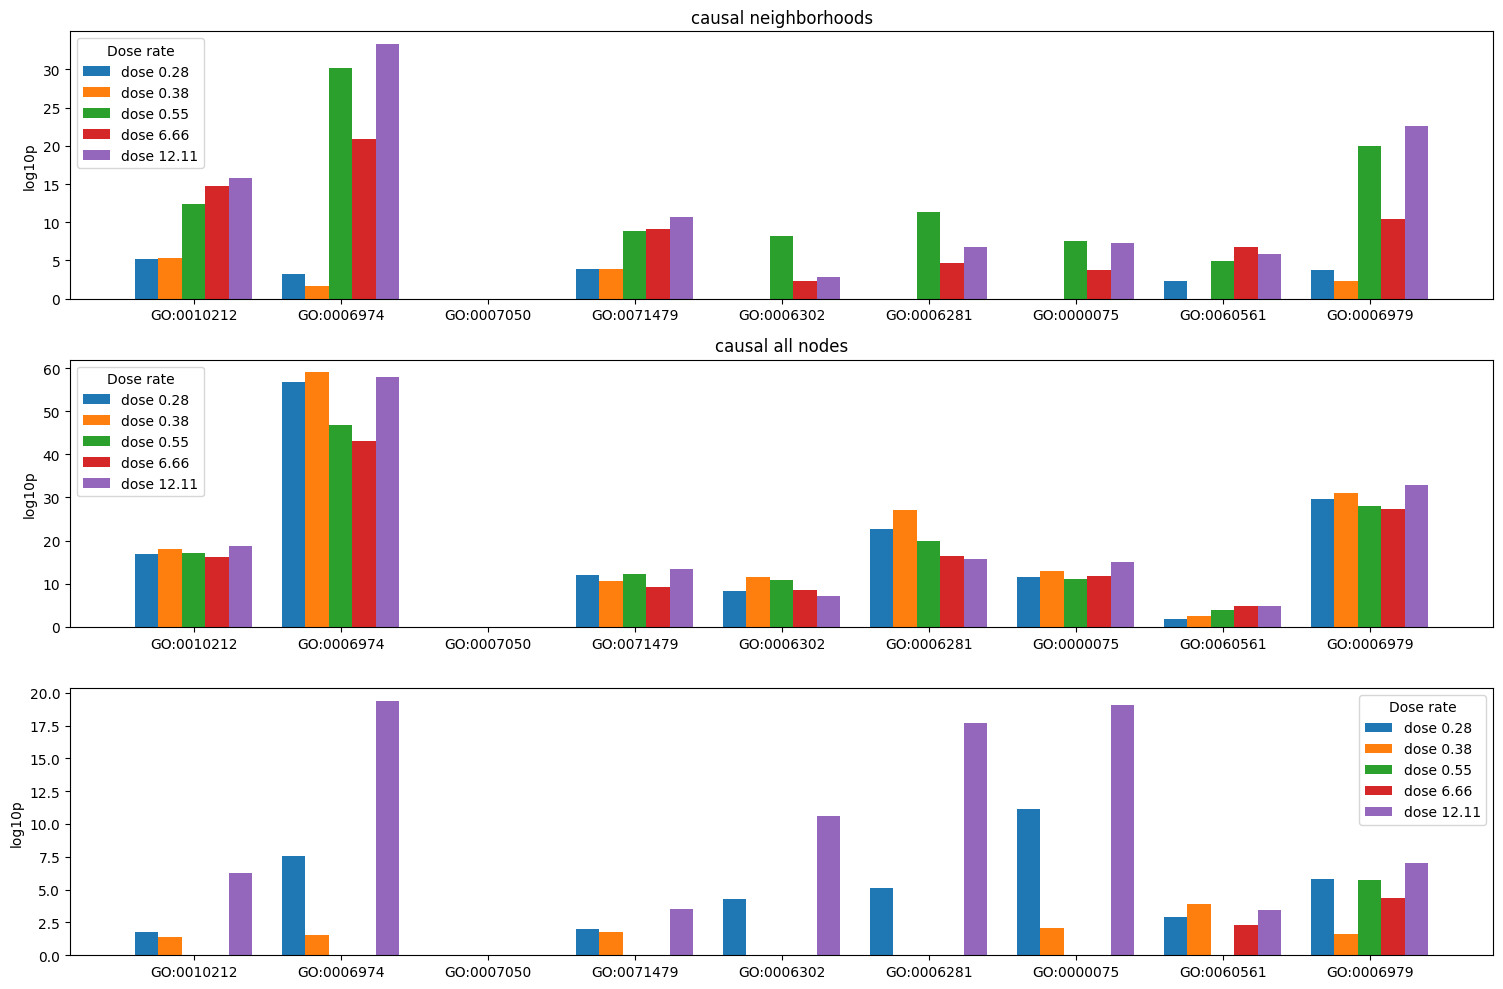

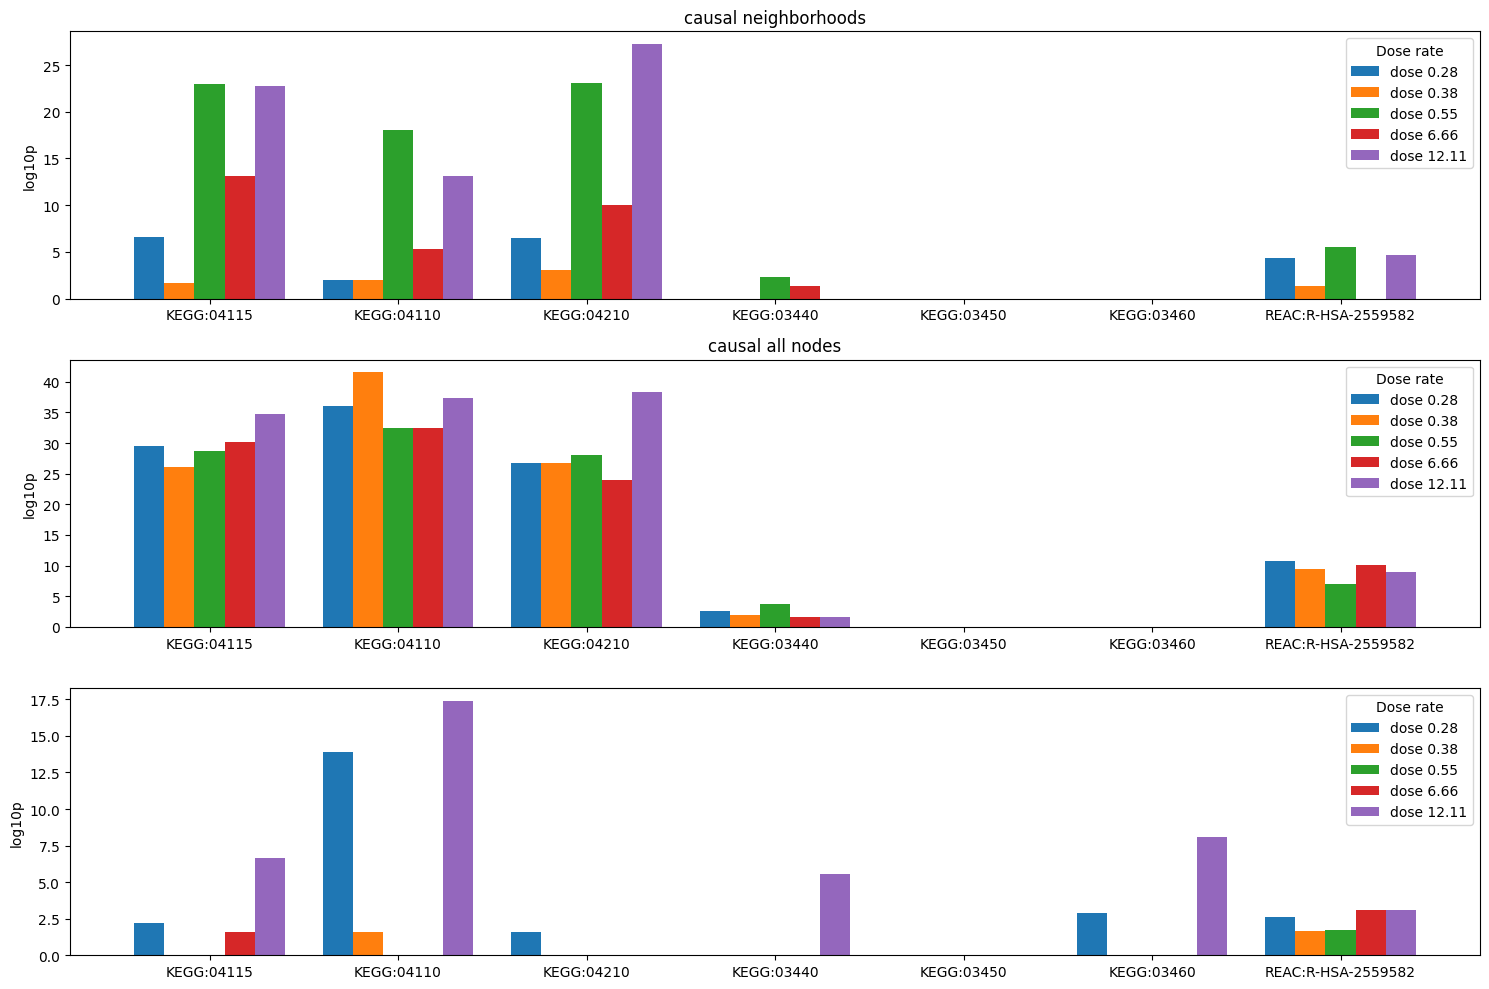

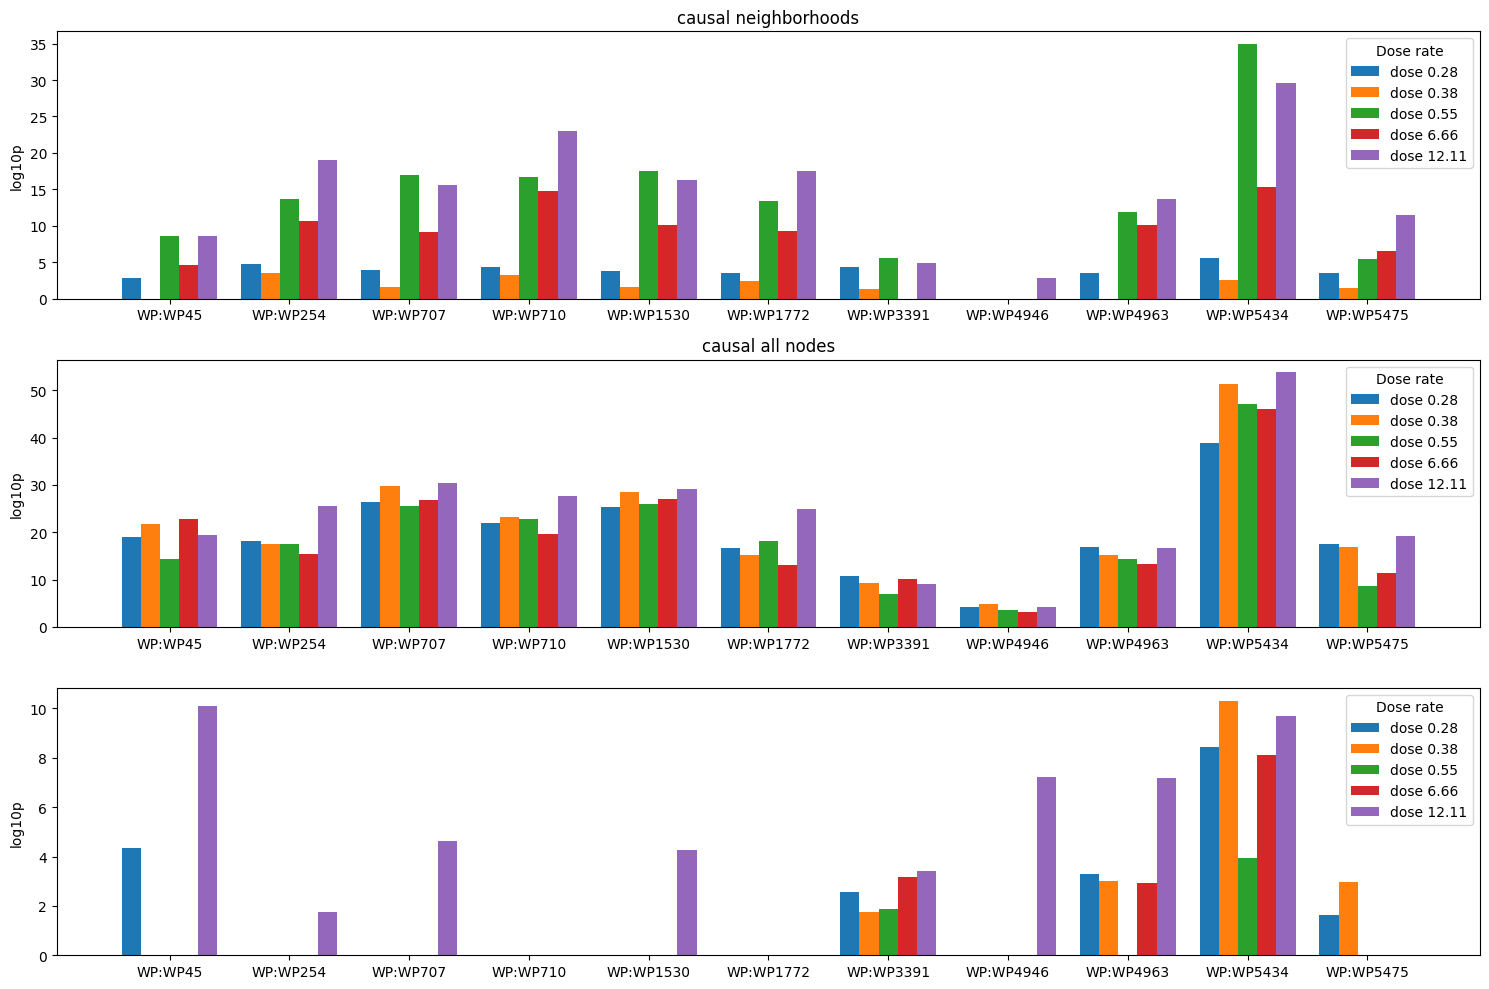

In [ ]:
names = ["G", "F", "H", "I", "J"]#, "invariant"]
methods = ["causal neighborhoods", "causal all nodes", "differentially expressed genes"]
pathway_types = ["GO Biological Processes", "KEGG Pathways", "WikiPathways"]
for pathways in [GOBP_pathways, KEGG_pathways, radiation_WP_pathways]:
    causal_neighborhood_pe = [pathway_enrichment(genes_neighborhoods[d], all_tpm_genes, pathways) for d in DOSE_RATES+["all_doses_dose_rate"]]
    causal_pe = [pathway_enrichment(graphs_genes_by_dose[d], all_tpm_genes, pathways) for d in DOSE_RATES+["invariant"]]
    log2fold_pe = [pathway_enrichment(genes_by_dose[d], all_tpm_genes, pathways) for d in DOSE_RATES]
    enrichment = [causal_neighborhood_pe, causal_pe, log2fold_pe]

    x = np.arange(len(pathways))
    total_width = 0.8
    bar_width = total_width / len(names)

    fig, ax = plt.subplots(len(methods), figsize=(15, 10))
    
    for j in range(len(methods)):
        for i in range(len(names)):
            p_values = []
            if names[i] == "invariant" and methods[j] == "differentially expressed genes":
                continue
            pe = enrichment[j][i]        
            for p in pathways:
                if p in list(pe['native']):
                    p_values.append(-np.log10(pe.loc[pe['native']==p]['p_value'].values[0]))
                else:
                    p_values.append(0)
            ax[j].bar(
                x - total_width/2 + i * bar_width + bar_width/2,
                p_values,
                width=bar_width,
                label=f"dose {DOSE_RATES_ACTUAL[names[i]]}"
            )
            ax[j].set_xticks(x)
            ax[j].set_xticklabels(pathways)
            ax[j].set_ylabel("log10p")
            ax[j].legend(title="Dose rate")
            ax[j].set_title(methods[j])
    plt.title("")
    plt.tight_layout()
    plt.show()

# Verify 3.1
- Same as above but along the temporal axis.
- Since we only have information about this for DE genes, for now we can only do this for log2fold DE data

It looks like the larger gene sets (weeks 2,3,6) have higher overall enrichment. But others do not. SASP, ROS, apoptotic pathways have enrichment across most of the weeks. But its not like at earlier times, we see specific pathways enriched and at later times there are other pathways enriched

In [ ]:
genes_by_week_flipped = {}
for i in WEEKS:
    gene_week = []
    for gene, t in genes_by_week.items():
        if i in t and (gene in genes_by_dose["J"]):
            gene_week.append(gene)
    genes_by_week_flipped[i] = set(gene_week)

In [ ]:
for i, genes in genes_by_week_flipped.items():
    print(len(genes))

0
442
1821
1142
849
342
1058
350
821
602


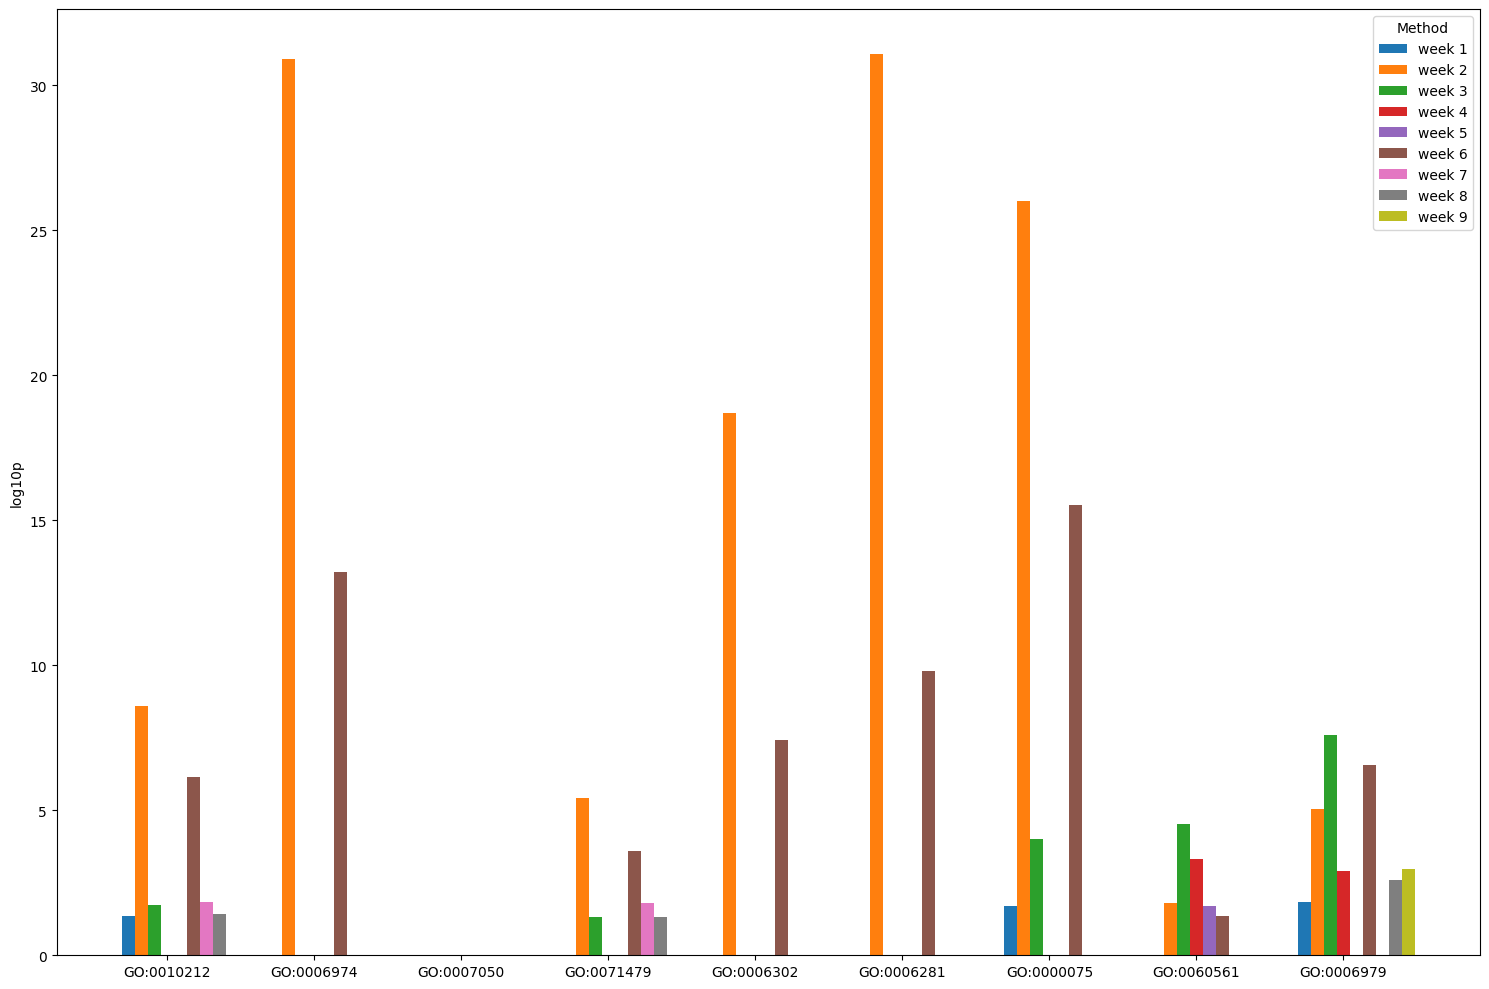

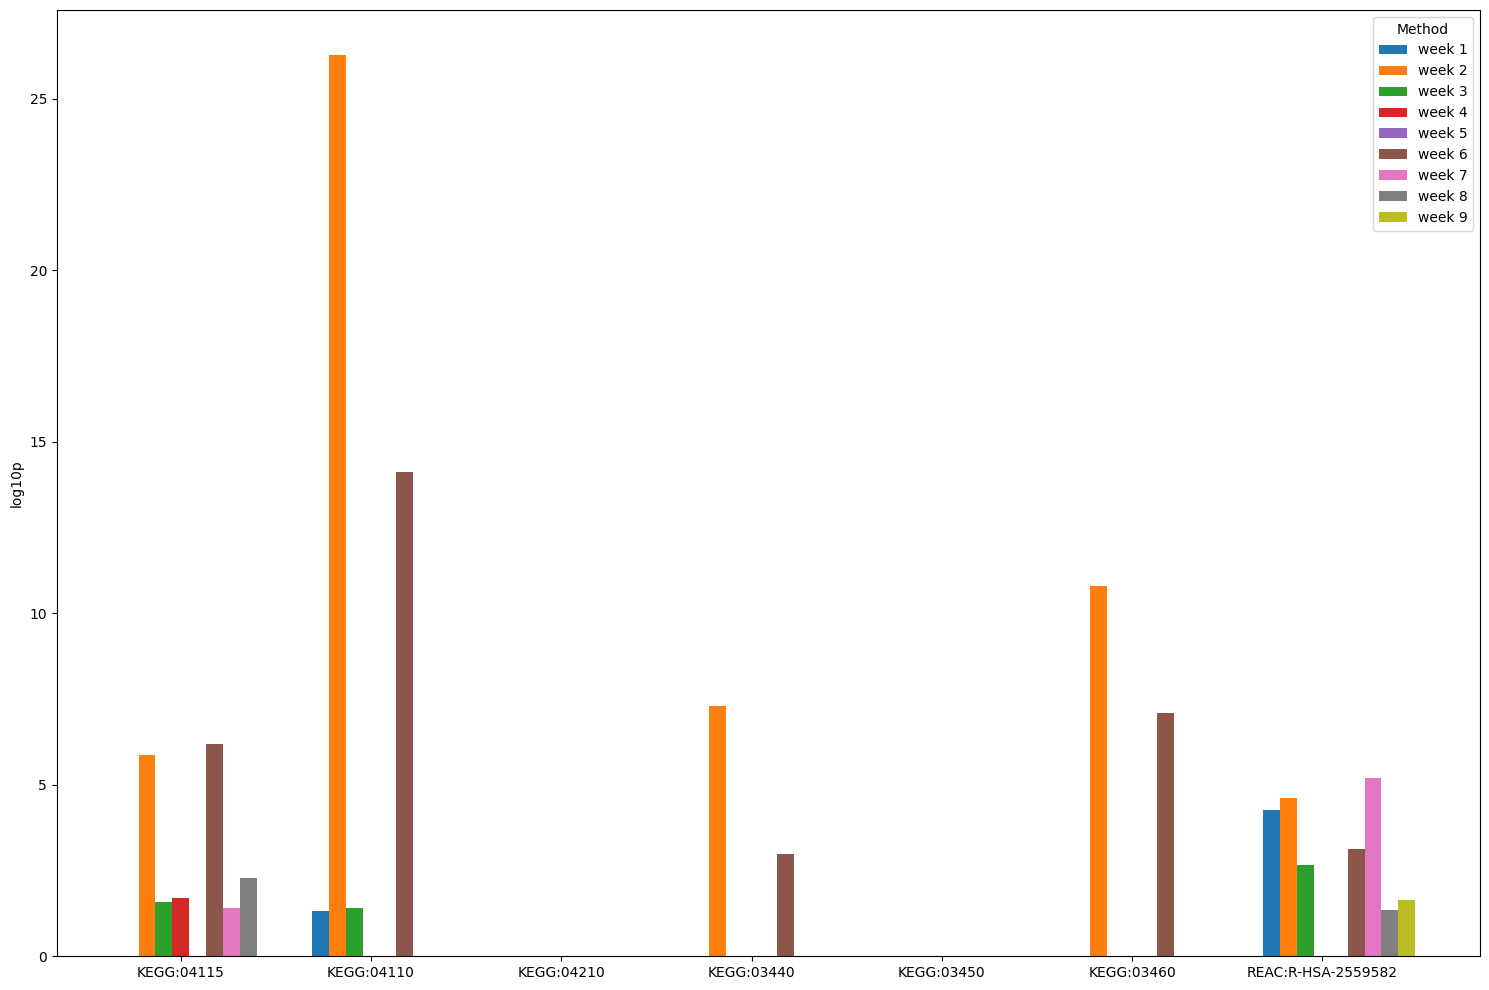

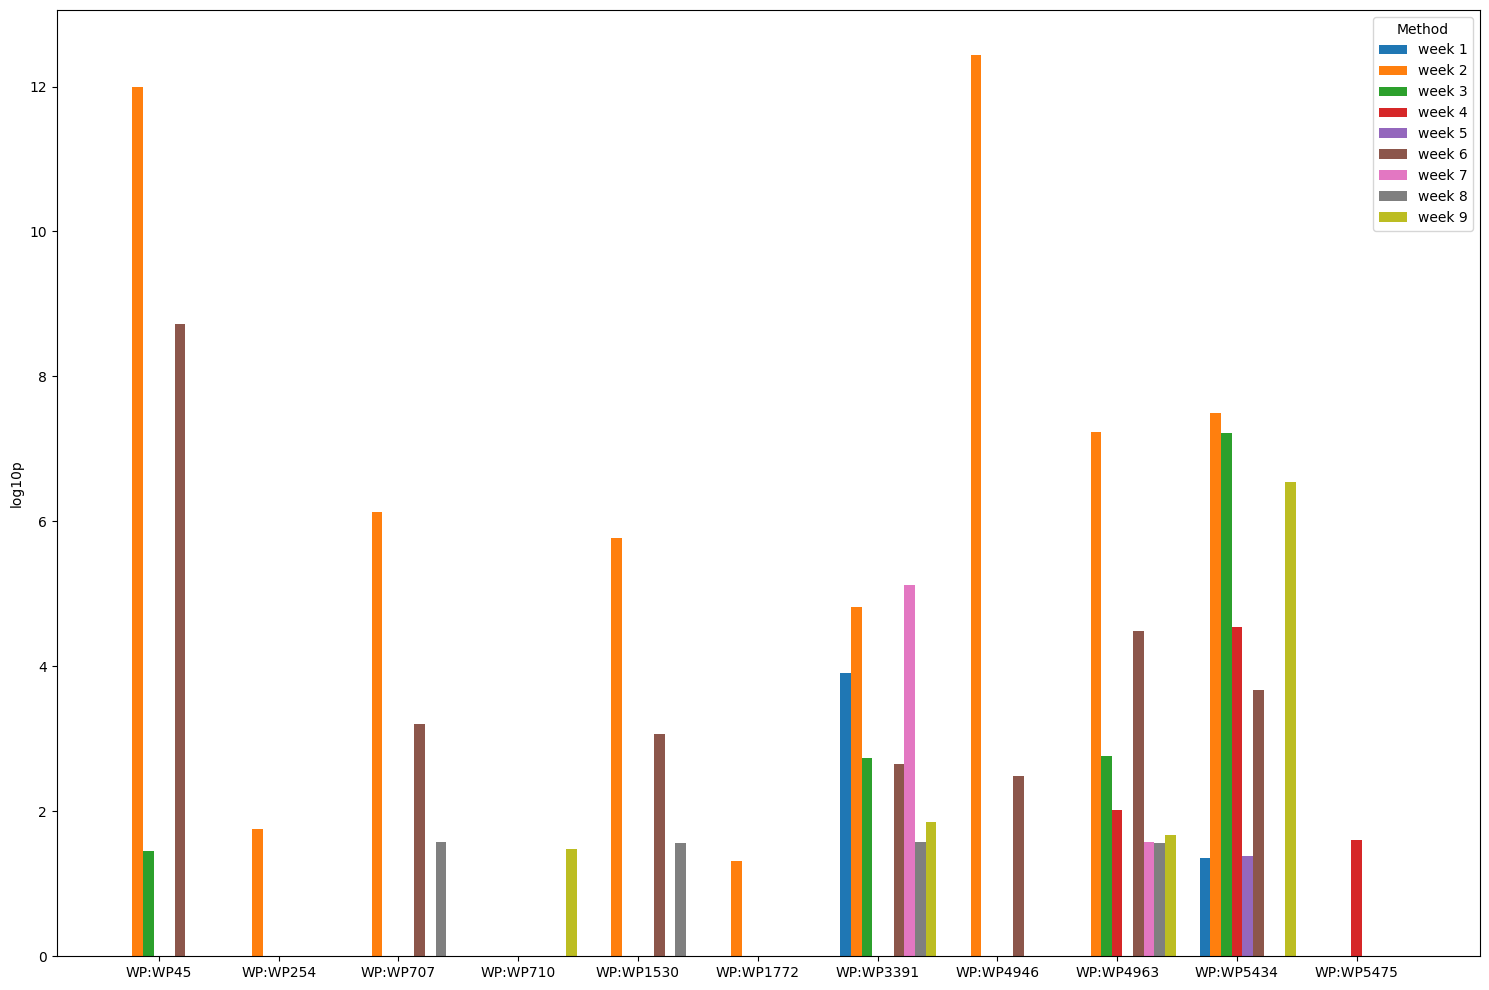

In [ ]:
for pathways in [GOBP_pathways, KEGG_pathways, radiation_WP_pathways]:
    log2fold_pe = [pathway_enrichment(genes_by_week_flipped[w], all_tpm_genes, pathways) for w in WEEKS[1:]]
    x = np.arange(len(pathways))
    total_width = 0.8
    bar_width = total_width / (len(WEEKS)-1)

    fig, ax = plt.subplots(1, figsize=(15, 10))

    for w in WEEKS[1:]:
        pe = log2fold_pe[w-1]  
        p_values = []      
        for p in pathways:
            if p in list(pe['native']):
                p_values.append(-np.log10(pe.loc[pe['native']==p]['p_value'].values[0]))
            else:
                p_values.append(0)
        ax.bar(
            x - total_width/2 + w * bar_width + bar_width/2,
            p_values,
            width=bar_width,
            label=f"week {w}"
        )
        ax.set_xticks(x)
        ax.set_xticklabels(pathways)
        ax.set_ylabel("log10p")
        ax.legend(title="Method")
        ax.set_title("log2fold")
    plt.title("")
    plt.tight_layout()
    plt.show()

## Verify 3.2
- How do KOSMOS and ChatGPT do with pathway enrichment? 

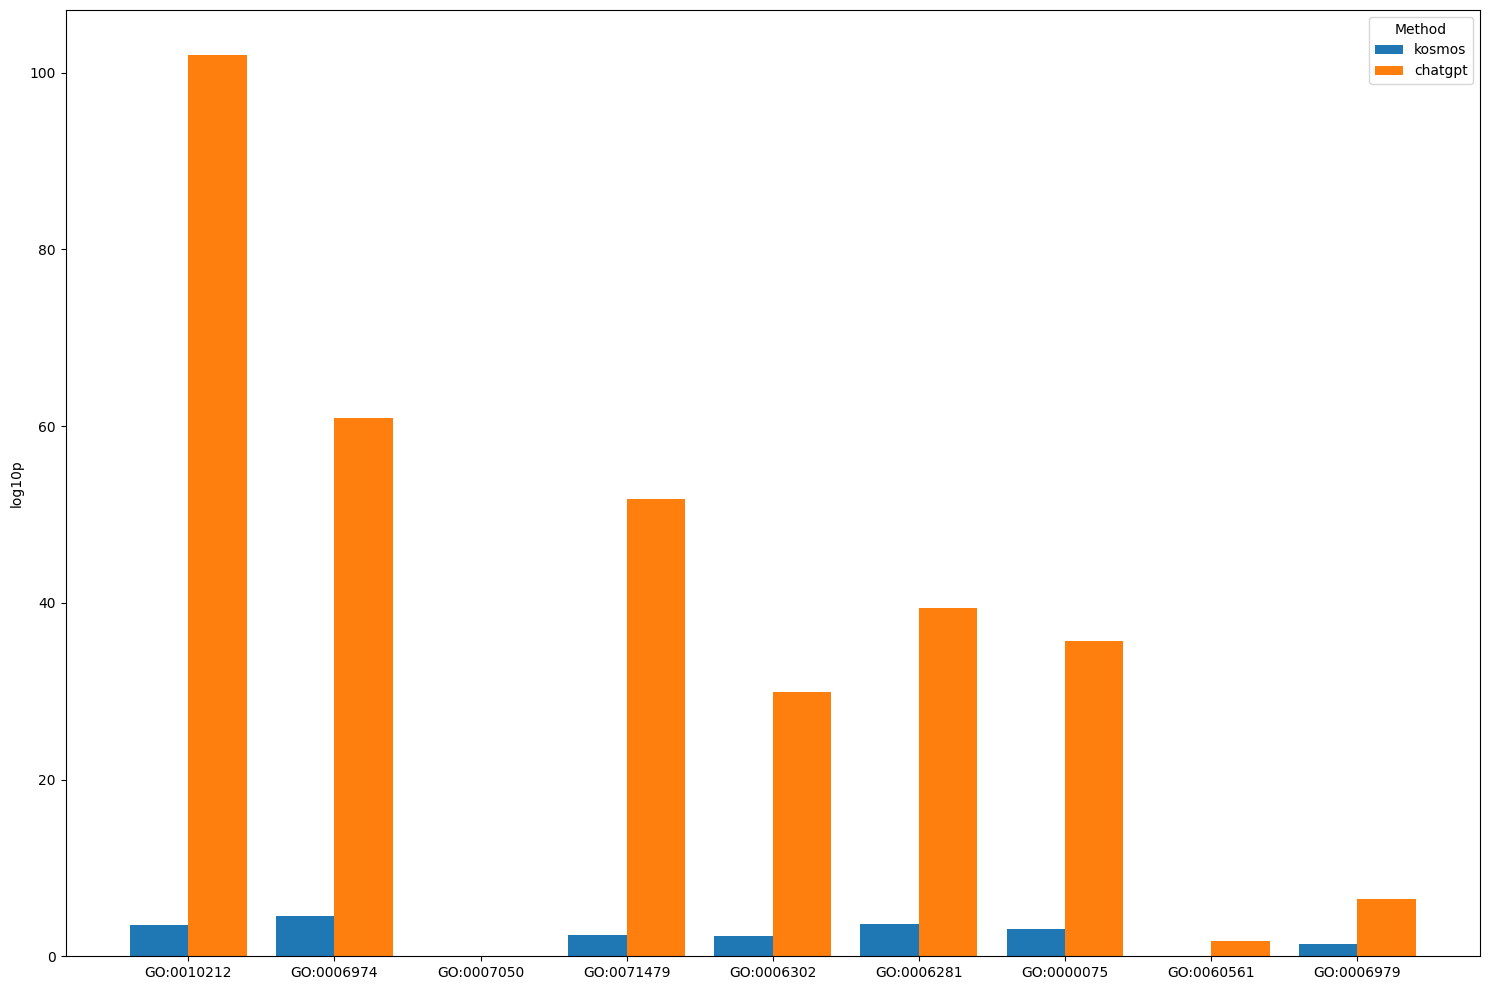

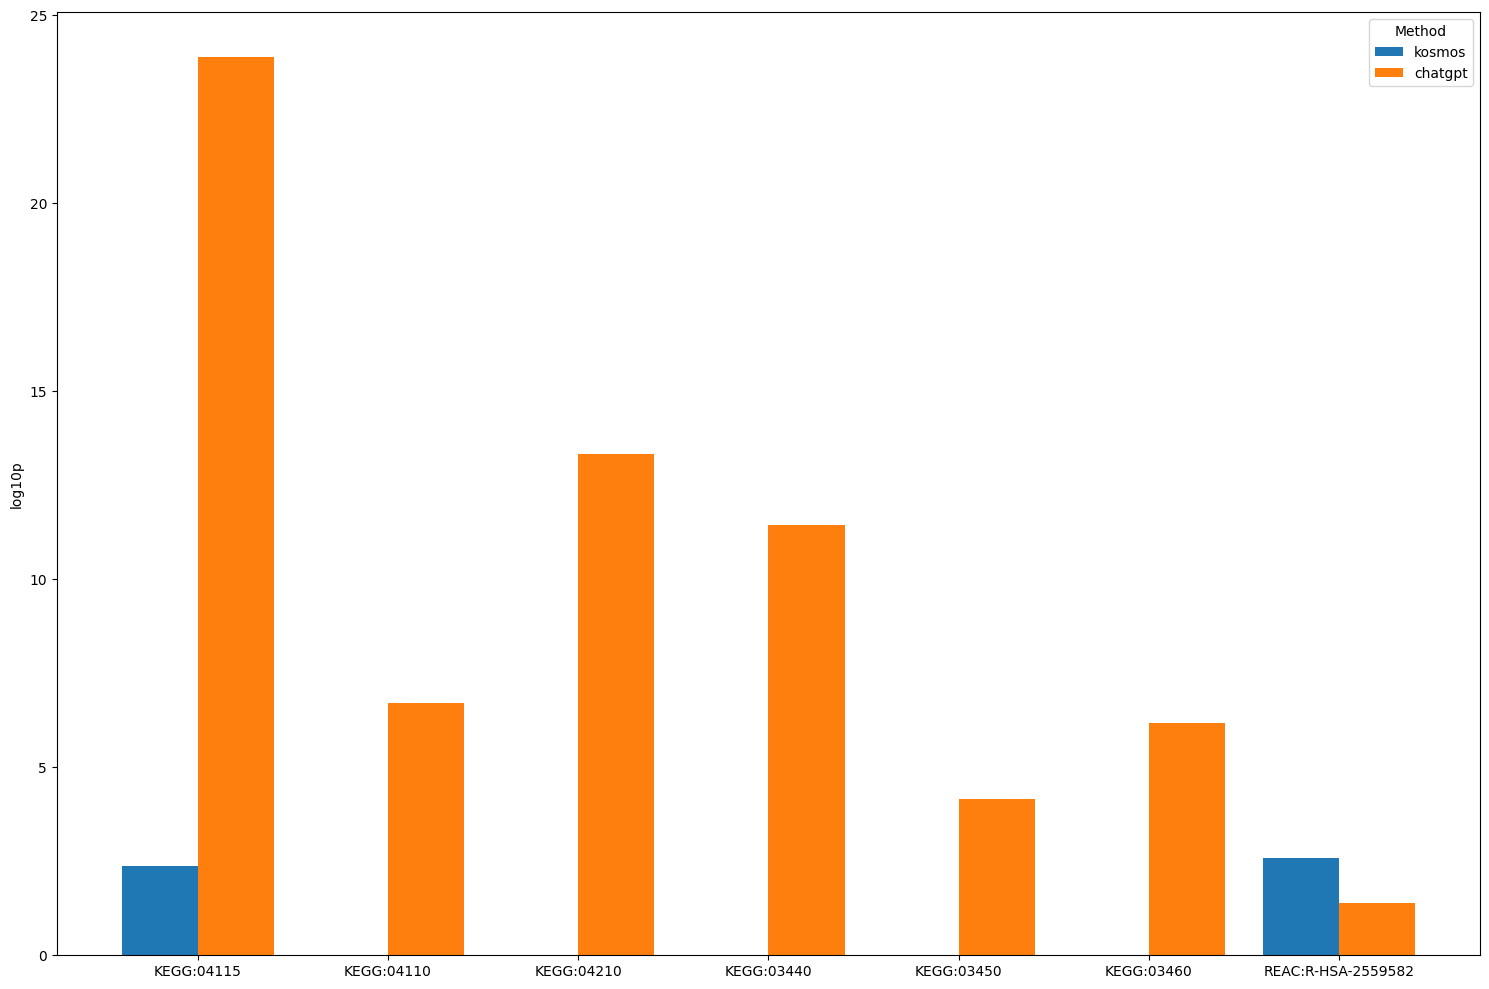

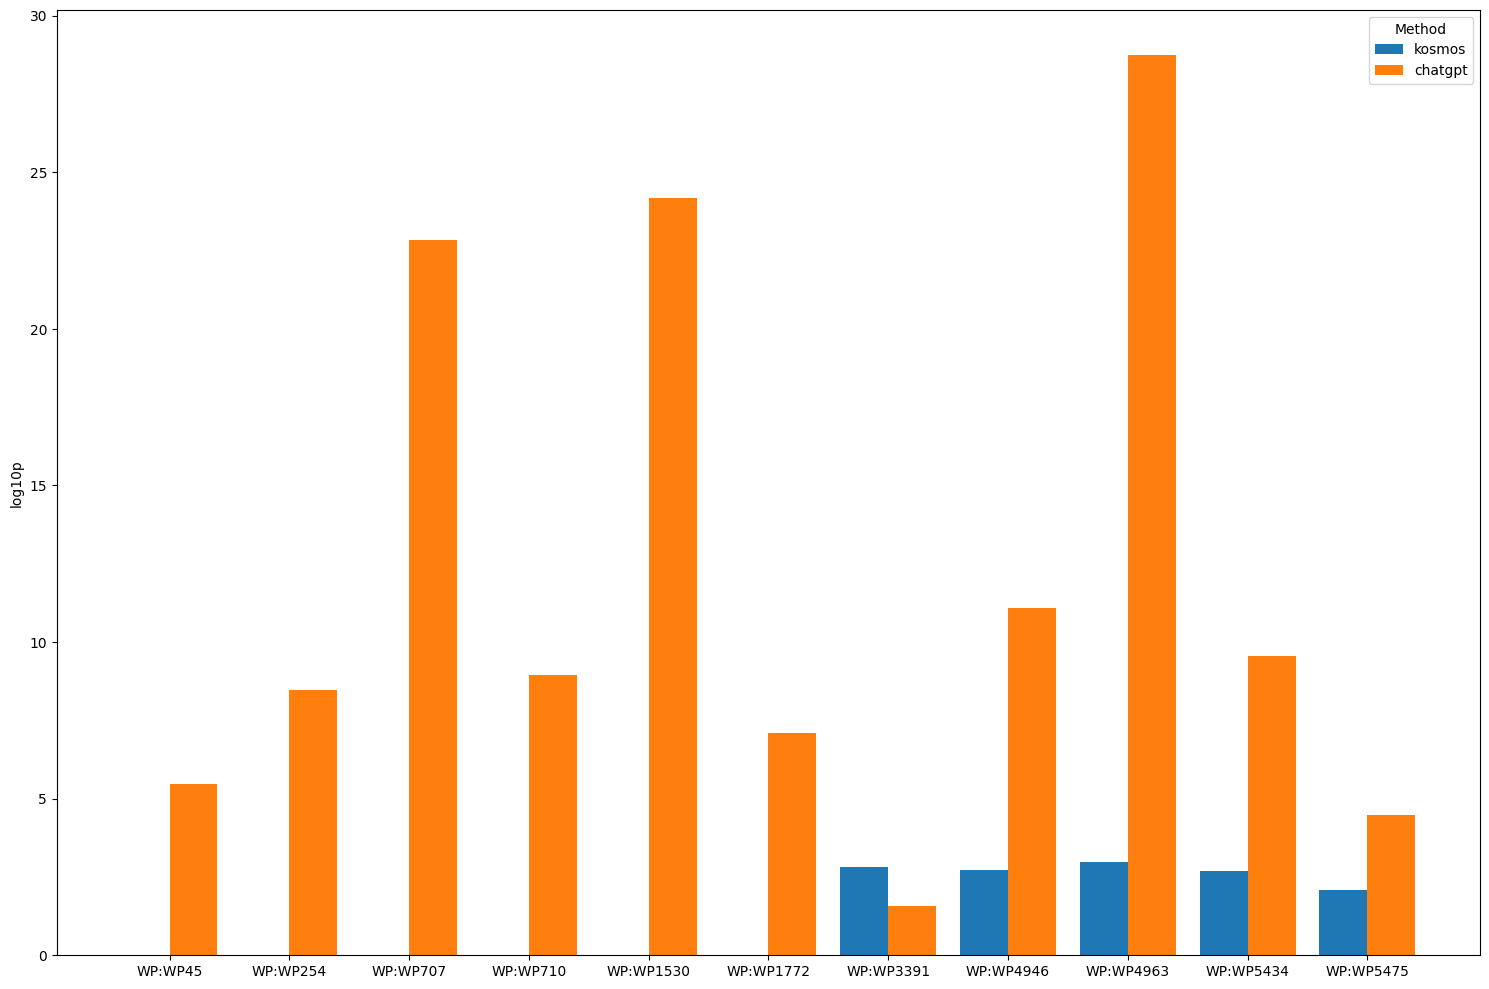

In [ ]:
for pathways in [GOBP_pathways, KEGG_pathways, radiation_WP_pathways]:
    enrichment = {"kosmos": pathway_enrichment(KOSMOS, all_tpm_genes, pathways),"chatgpt": pathway_enrichment(CHATGPT, all_tpm_genes, pathways)}
    x = np.arange(len(pathways))
    total_width = 0.8
    bar_width = total_width / 2

    fig, ax = plt.subplots(1, figsize=(15, 10))

    for i,(name, pe) in enumerate(enrichment.items()):
        p_values = []      
        for p in pathways:
            if p in list(pe['native']):
                p_values.append(-np.log10(pe.loc[pe['native']==p]['p_value'].values[0]))
            else:
                p_values.append(0)
        ax.bar(
            x - total_width/2 + i * bar_width + bar_width/2,
            p_values,
            width=bar_width,
            label=name
        )
        ax.set_xticks(x)
        ax.set_xticklabels(pathways)
        ax.set_ylabel("log10p")
        ax.legend(title="Method")
        ax.set_title("log2fold")
    plt.title("")
    plt.tight_layout()
    plt.show()

## Figure 1

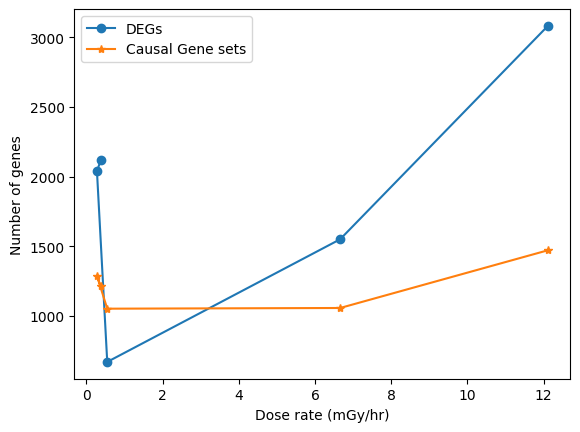

In [20]:
plt.plot([DOSE_RATES_ACTUAL[d] for d in df_genes.index], df_genes["DE"], label="DEGs", marker="o")
plt.plot([DOSE_RATES_ACTUAL[d] for d in df_genes.index], df_genes["Causal"], label="Causal Gene sets", marker='*')
plt.xlabel("Dose rate (mGy/hr)")
plt.ylabel("Number of genes")
plt.legend()

- Pathway enrichment by algorithm: DE, Causal (full, neighborhood)
- Stack the doses
- Choose specific pathways and sort by type
- Choose top 10 enriched pathways for each 

In [31]:
all_radiation_pathways = GOBP_pathways + KEGG_pathways + radiation_WP_pathways 
all_causal = [pathway_enrichment(graphs_genes_by_dose[d], all_tpm_genes, None) for d in DOSE_RATES]
all_de = [pathway_enrichment(genes_by_dose[d], all_tpm_genes, None) for d in DOSE_RATES]
all_de_neighborhoods = [pathway_enrichment(genes_neighborhoods[d], all_tpm_genes, None) for d in DOSE_RATES]

In [ ]:
all_data_causal = {"pathways": all_radiation_pathways}
all_data_de = {"pathways": all_radiation_pathways}
all_data_neighborhoods = {"pathways": all_radiation_pathways}

for i,d in enumerate(DOSE_RATES):
    causal_list = []
    de_list = []
    neighborhood_list = []
    for p in all_radiation_pathways:
        pe_causal = all_causal[i]
        pe_de = all_de[i]
        pe_neighborhood = all_de_neighborhoods[i]
        if p in list(pe_causal['native']):
            causal_list.append(-np.log10(pe_causal.loc[pe_causal['native']==p]['p_value'].values[0]))
        else:
            causal_list.append(0)
        if p in list(pe_neighborhood['native']):
            neighborhood_list.append(-np.log10(pe_neighborhood.loc[pe_neighborhood['native']==p]['p_value'].values[0]))
        else:
            neighborhood_list.append(0)
    all_data_causal[DOSE_RATES_ACTUAL[d]] = causal_list
    all_data_de[DOSE_RATES_ACTUAL[d]] = de_list
    all_data_neighborhoods[DOSE_RATES_ACTUAL[d]] = neighborhood_list


KeyError: 0

In [33]:
set(all_causal[0]['source'].values)
all_causal[0].sort_values(by='p_value', ascending=True)['term_size']

0       15078
1       17024
2       18440
3       15892
4       14214
        ...  
6082       39
6083       68
6084       68
6085       30
6086       44
Name: term_size, Length: 6087, dtype: int64

In [ ]:
all_data_causal.keys()

dict_keys(['pathways', 0.38, 0.28, 0.55, 6.66, 12.11])

Index([0.28, 0.38, 0.55, 6.66, 12.11], dtype='object')


/tmp/ipykernel_3371812/932030351.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis')


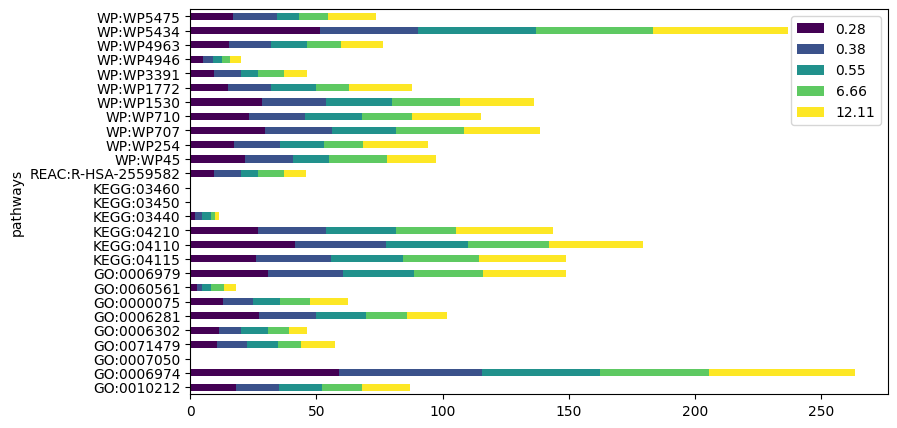

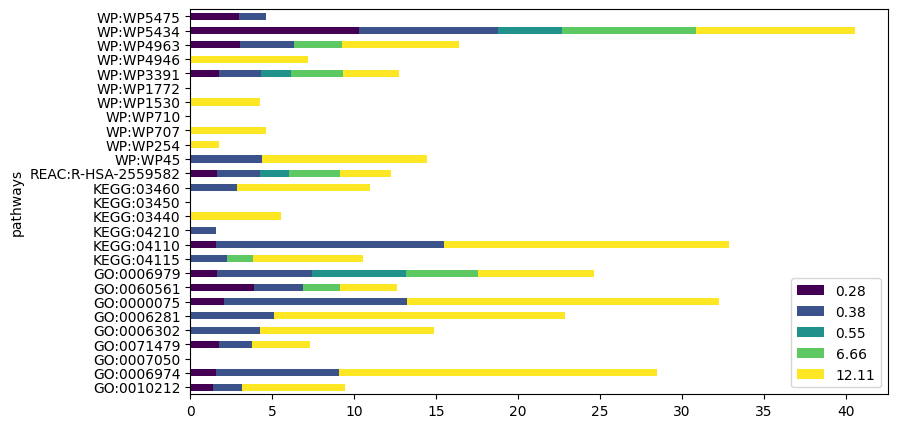

In [ ]:
import matplotlib.cm as cm

df_causal = pd.DataFrame(all_data_causal).set_index('pathways').sort_index(axis=1)
df_de = pd.DataFrame(all_data_de).set_index('pathways').sort_index(axis=1)
print(df_causal.columns)
cmap = cm.get_cmap('viridis')
ax = df_causal.plot(kind='barh', stacked=True, figsize=(9, 5), cmap=cmap)
ax2 = df_de.plot(kind='barh', stacked=True, figsize=(9, 5), cmap=cmap)


In [ ]:
# TODO sort by name relevance 
pathway_categories = {
    "DNA_damage_response": [
        "GO:0010212",  # response to ionizing radiation
        "GO:0006974",  # DNA damage response
        "GO:0071479",  # cellular response to ionizing radiation
        "WP:WP45",     # DNA damage response
        "WP:WP4946",   # radiation-induced signaling
        "WP:WP5434",   # DNA damage checkpoint
    ],

    "DNA_repair": [
        "GO:0006302",       # double-strand break repair
        "GO:0006281",       # DNA repair
        "KEGG:03440",       # homologous recombination
        "KEGG:03450",       # non-homologous end joining
        "KEGG:03460",       # Fanconi anemia pathway
        "REAC:R-HSA-2559582",  # DNA Double-Strand Break Repair
        "WP:WP1772",        # DNA repair mechanisms
    ],

    "cell_cycle_checkpoints": [
        "GO:0000075",  # cell cycle checkpoint
        "GO:0007050",  # cell cycle arrest
        "KEGG:04110",  # cell cycle
        "WP:WP3391",   # cell cycle regulation
        "WP:WP5434",   # DNA damage checkpoint
    ],

    "apoptosis_cell_fate": [
        "GO:0060561",  # apoptotic process involved in morphogenesis
        "KEGG:04210",  # apoptosis
        "KEGG:04115",  # p53 signaling pathway
        "WP:WP710",    # apoptosis pathway
        "WP:WP707",    # p53 pathway
    ],

    "oxidative_stress_signaling": [
        "GO:0006979",  # response to oxidative stress
        "WP:WP254",    # oxidative stress response
        "WP:WP1530",   # ATM signaling pathway
        "WP:WP4963",   # cellular stress response
        "WP:WP5475",   # genotoxic stress response
    ],
}

        incoming        converted  n_incoming  n_converted    name  \
0     GO:0010212  ENSG00000004487           1            1   KDM1A   
1     GO:0010212  ENSG00000012048           1            2   BRCA1   
2     GO:0010212  ENSG00000012061           1            3   ERCC1   
3     GO:0010212  ENSG00000019549           1            4   SNAI2   
4     GO:0010212  ENSG00000030110           1            5    BAK1   
...          ...              ...         ...          ...     ...   
4675   WP:WP5475  ENSG00000198400          27           94   NTRK1   
4676   WP:WP5475  ENSG00000198793          27           95    MTOR   
4677   WP:WP5475  ENSG00000204673          27           96  AKT1S1   
4678   WP:WP5475  ENSG00000213341          27           97    CHUK   
4679   WP:WP5475  ENSG00000269335          27           98   IKBKG   

                                            description namespaces    query  
0     lysine demethylase 1A [Source:HGNC Symbol;Acc:...         GO  query_1  
1  